# ============================================================
# MODEL BUILDING — Resume Category Classifier
# AI Resume Rewriting System using OpenAI GPT-4o-mini
# ============================================================
# Objective:
#   Build a model that classifies a resume into the correct
#   job category — this powers the "role-specific keyword
#   alignment" in the resume rewriting system.
#
# Steps:
#   1. Load & Preprocess Dataset
#   2. TF-IDF Feature Extraction
#   3. Train/Test Split
#   4. Train 3 Models (Logistic Regression, SVM, Random Forest)
#   5. Evaluate (Accuracy, F1, Confusion Matrix)
#   6. Select Best Model
#   7. Save Model for app.py
# ============================================================

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Resume.csv to Resume.csv


In [2]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [3]:
# ── PLOT SETTINGS ─────────────────────────────────────────────────────────────
BG      = "#0D0D0D"
ACCENT1 = "#00FFB2"
ACCENT2 = "#FF4D6D"
ACCENT3 = "#FFD166"
ACCENT4 = "#00D4FF"
TEXT    = "#E8E8E8"

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'axes.edgecolor': '#2A2A2A', 'grid.color': '#1E1E1E',
})

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — LOAD & PREPROCESS
# ══════════════════════════════════════════════════════════════════════════════
print("="*60)
print("STEP 1 — Loading & Preprocessing Dataset")
print("="*60)

df = pd.read_csv('Resume.csv')
df['Resume_str'] = df['Resume_str'].astype(str)

print(f"Shape         : {df.shape}")
print(f"Categories    : {df['Category'].nunique()}")
print(f"Null values   : {df.isnull().sum().sum()}")
print(f"\nCategory distribution:\n{df['Category'].value_counts()}")

# ── Text Cleaning ──────────────────────────────────────────────────────────────
STOPWORDS = {
    'the','and','to','of','in','a','is','for','with','on','as','at','by',
    'be','this','that','are','was','from','it','an','have','has','or','not',
    'we','i','my','me','our','their','will','been','had','but','so','if',
    'do','all','more','they','he','she','you','your','its','can','which','who'
}

def clean_text(text):
    text = re.sub(r'http\S+', ' ', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)      # remove special chars
    text = text.lower()
    return ' '.join(
        w for w in text.split()
        if w not in STOPWORDS and len(w) > 2
    )

df['clean_resume'] = df['Resume_str'].apply(clean_text)
df['word_count']   = df['clean_resume'].apply(lambda x: len(x.split()))

print(f"\n✅ Text cleaning done")
print(f"Avg word count after cleaning: {df['word_count'].mean():.0f}")

# ── Label Encoding ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print(f"\n✅ Labels encoded: {le.classes_[:5]} ...")
print(f"Total classes: {len(le.classes_)}")

X = df['clean_resume']
y = df['label']

STEP 1 — Loading & Preprocessing Dataset
Shape         : (2484, 4)
Categories    : 24
Null values   : 0

Category distribution:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

✅ Text cleaning done
Avg word count after cleaning: 596

✅ Labels encoded: ['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'A

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — TF-IDF FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 2 — TF-IDF Feature Extraction")
print("="*60)

tfidf = TfidfVectorizer(
    max_features=5000,      # top 5000 features
    ngram_range=(1, 2),     # unigrams + bigrams
    sublinear_tf=True,      # log normalization
    min_df=2,               # ignore rare terms
)

X_tfidf = tfidf.fit_transform(X)

print(f"TF-IDF Matrix Shape : {X_tfidf.shape}")
print(f"Features (vocab)    : {len(tfidf.vocabulary_)}")
print(f"ngram_range         : (1, 2)  — unigrams + bigrams")
print(f"max_features        : 5000")
print(f"sublinear_tf        : True (log normalization)")
print("✅ TF-IDF features extracted")


STEP 2 — TF-IDF Feature Extraction
TF-IDF Matrix Shape : (2484, 5000)
Features (vocab)    : 5000
ngram_range         : (1, 2)  — unigrams + bigrams
max_features        : 5000
sublinear_tf        : True (log normalization)
✅ TF-IDF features extracted


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 3 — Train / Test Split")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.20,         # 80% train, 20% test
    random_state=42,
    stratify=y              # preserve class distribution
)

print(f"Total samples   : {X_tfidf.shape[0]}")
print(f"Training set    : {X_train.shape[0]} samples (80%)")
print(f"Testing set     : {X_test.shape[0]} samples (20%)")
print(f"Stratified      : Yes — class balance preserved")
print("✅ Train/Test split done")



STEP 3 — Train / Test Split
Total samples   : 2484
Training set    : 1987 samples (80%)
Testing set     : 497 samples (20%)
Stratified      : Yes — class balance preserved
✅ Train/Test split done


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — MODEL TRAINING (3 Models)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 4 — Training 3 Models")
print("="*60)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=1.0,
        multi_class='multinomial',
        solver='lbfgs', random_state=42
    ),
    "Linear SVM": LinearSVC(
        C=1.0, max_iter=2000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=20,
        random_state=42, n_jobs=-1
    )
}

results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n   Training: {name} ...")
    start = __import__('time').time()
    model.fit(X_train, y_train)
    elapsed = __import__('time').time() - start

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')

    # Cross Validation (5-fold)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tfidf, y, cv=cv,
                                 scoring='accuracy', n_jobs=-1)

    results[name] = {
        'accuracy'   : round(acc * 100, 2),
        'f1_score'   : round(f1 * 100, 2),
        'cv_mean'    : round(cv_scores.mean() * 100, 2),
        'cv_std'     : round(cv_scores.std() * 100, 2),
        'train_time' : round(elapsed, 2)
    }
    trained_models[name] = model

    print(f"   ✅ {name}")
    print(f"      Test Accuracy   : {acc*100:.2f}%")
    print(f"      Weighted F1     : {f1*100:.2f}%")
    print(f"      CV Mean (5-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"      Train Time      : {elapsed:.2f}s")


STEP 4 — Training 3 Models

   Training: Logistic Regression ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


   ✅ Logistic Regression
      Test Accuracy   : 66.60%
      Weighted F1     : 64.65%
      CV Mean (5-fold): 65.14% ± 0.85%
      Train Time      : 4.30s

   Training: Linear SVM ...
   ✅ Linear SVM
      Test Accuracy   : 71.83%
      Weighted F1     : 70.52%
      CV Mean (5-fold): 71.34% ± 0.93%
      Train Time      : 0.76s

   Training: Random Forest ...
   ✅ Random Forest
      Test Accuracy   : 72.84%
      Weighted F1     : 69.82%
      CV Mean (5-fold): 71.46% ± 0.58%
      Train Time      : 2.54s



STEP 5 — Model Comparison

📋 Model Comparison Table:
              Model  Accuracy(%)  F1 Score(%)  CV Mean(%)  CV Std(%)  Train Time(s)
Logistic Regression        66.60        64.65       65.14       0.85           4.30
         Linear SVM        71.83        70.52       71.34       0.93           0.76
      Random Forest        72.84        69.82       71.46       0.58           2.54

🏆 Best Model: Random Forest with 72.84% accuracy


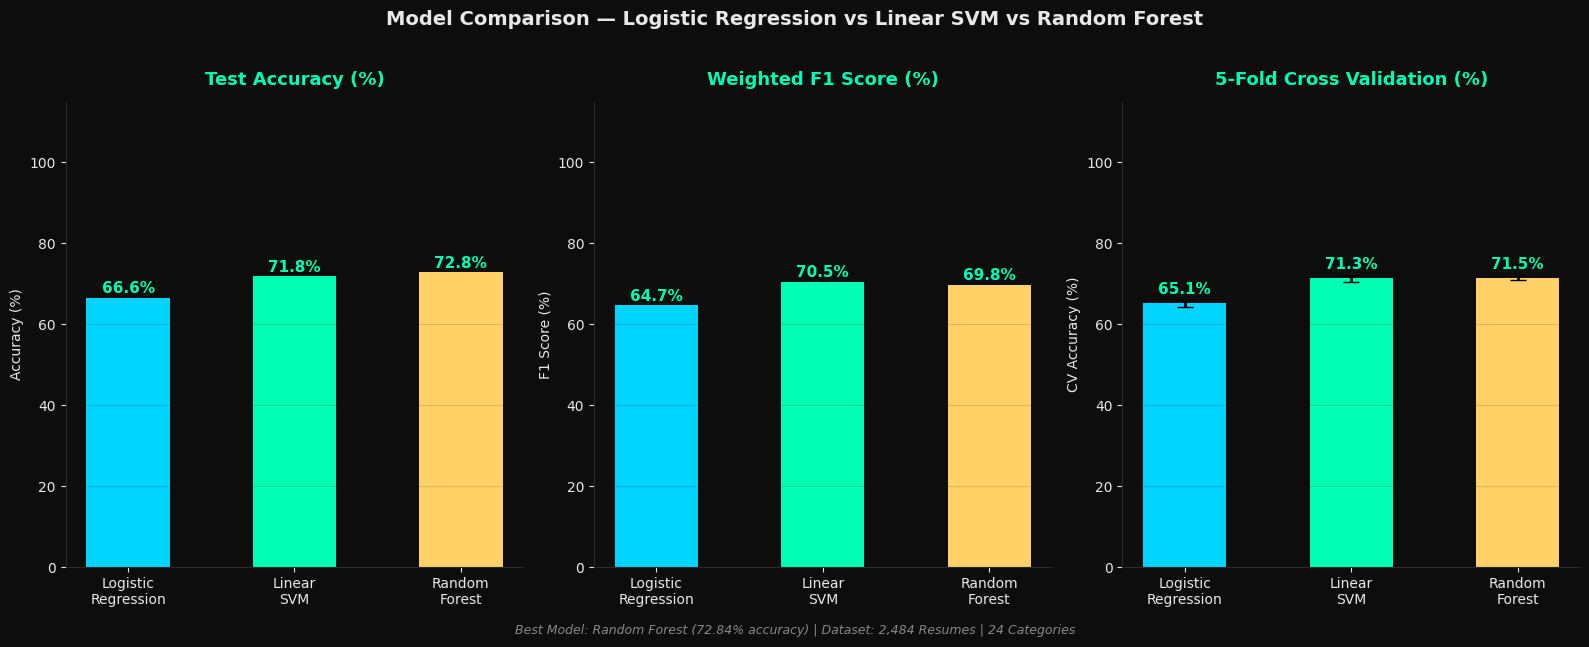

✅ Fig 7 — Model Comparison saved


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — MODEL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 5 — Model Comparison")
print("="*60)

results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy(%)', 'F1 Score(%)', 'CV Mean(%)', 'CV Std(%)', 'Train Time(s)']
print("\n📋 Model Comparison Table:")
print(results_df.to_string(index=False))

best_model_name = results_df.loc[results_df['Accuracy(%)'].idxmax(), 'Model']
best_accuracy   = results_df['Accuracy(%)'].max()
print(f"\n🏆 Best Model: {best_model_name} with {best_accuracy}% accuracy")

# ── Figure 7: Model Comparison Bar Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor=BG)

model_names = list(results.keys())
short_names = ['Logistic\nRegression', 'Linear\nSVM', 'Random\nForest']
acc_vals    = [results[m]['accuracy']  for m in model_names]
f1_vals     = [results[m]['f1_score']  for m in model_names]
cv_vals     = [results[m]['cv_mean']   for m in model_names]
cv_stds     = [results[m]['cv_std']    for m in model_names]

palette = [ACCENT4, ACCENT1, ACCENT3]

# Accuracy
ax = axes[0]
bars = ax.bar(short_names, acc_vals, color=palette, edgecolor='none', width=0.5)
for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, color=ACCENT1, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('Test Accuracy (%)', fontsize=13, fontweight='bold', color=ACCENT1, pad=12)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.grid(axis='y', alpha=0.15)
ax.spines[['top','right']].set_visible(False)

# F1 Score
ax = axes[1]
bars2 = ax.bar(short_names, f1_vals, color=palette, edgecolor='none', width=0.5)
for bar, val in zip(bars2, f1_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, color=ACCENT1, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('Weighted F1 Score (%)', fontsize=13, fontweight='bold', color=ACCENT1, pad=12)
ax.set_ylabel('F1 Score (%)', fontsize=10)
ax.grid(axis='y', alpha=0.15)
ax.spines[['top','right']].set_visible(False)

# Cross Validation
ax = axes[2]
bars3 = ax.bar(short_names, cv_vals, color=palette, edgecolor='none', width=0.5,
               yerr=cv_stds, capsize=6, error_kw={'color': '#ffffff', 'lw': 2})
for bar, val in zip(bars3, cv_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=11, color=ACCENT1, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('5-Fold Cross Validation (%)', fontsize=13, fontweight='bold', color=ACCENT1, pad=12)
ax.set_ylabel('CV Accuracy (%)', fontsize=10)
ax.grid(axis='y', alpha=0.15)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Model Comparison — Logistic Regression vs Linear SVM vs Random Forest',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)
fig.text(0.5, -0.02,
         f'Best Model: {best_model_name} ({best_accuracy}% accuracy) | Dataset: 2,484 Resumes | 24 Categories',
         ha='center', fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('fig7_model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Fig 7 — Model Comparison saved")


STEP 6 — Detailed Evaluation: Random Forest

📋 Classification Report (Random Forest):
                        precision    recall  f1-score   support

            ACCOUNTANT      0.697     0.958     0.807        24
              ADVOCATE      0.690     0.833     0.755        24
           AGRICULTURE      1.000     0.154     0.267        13
               APPAREL      0.857     0.316     0.462        19
                  ARTS      1.000     0.143     0.250        21
            AUTOMOBILE      0.000     0.000     0.000         7
              AVIATION      0.833     0.833     0.833        24
               BANKING      0.800     0.522     0.632        23
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.759     0.917     0.830        24
                  CHEF      0.909     0.833     0.870        24
          CONSTRUCTION      0.895     0.773     0.829        22
            CONSULTANT      0.688     0.478     0.564        23
              DE

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


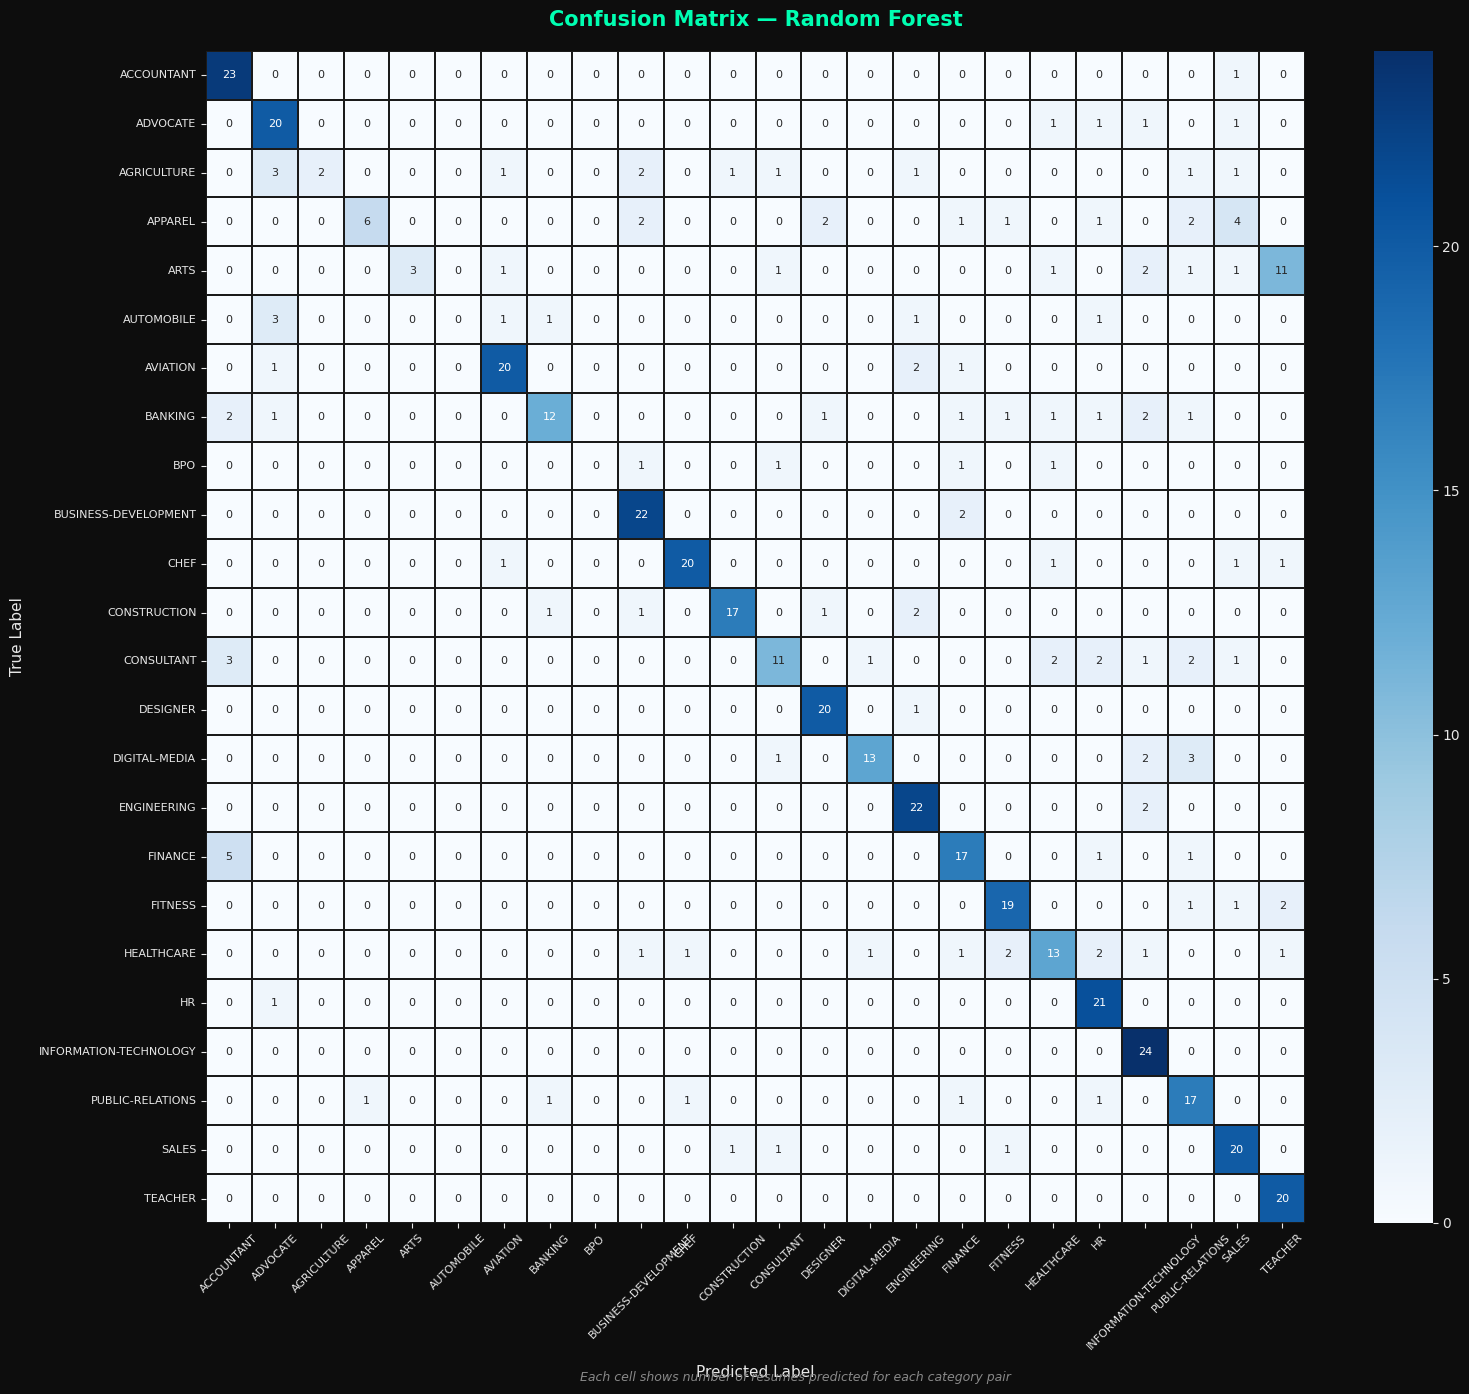

✅ Fig 8 — Confusion Matrix saved


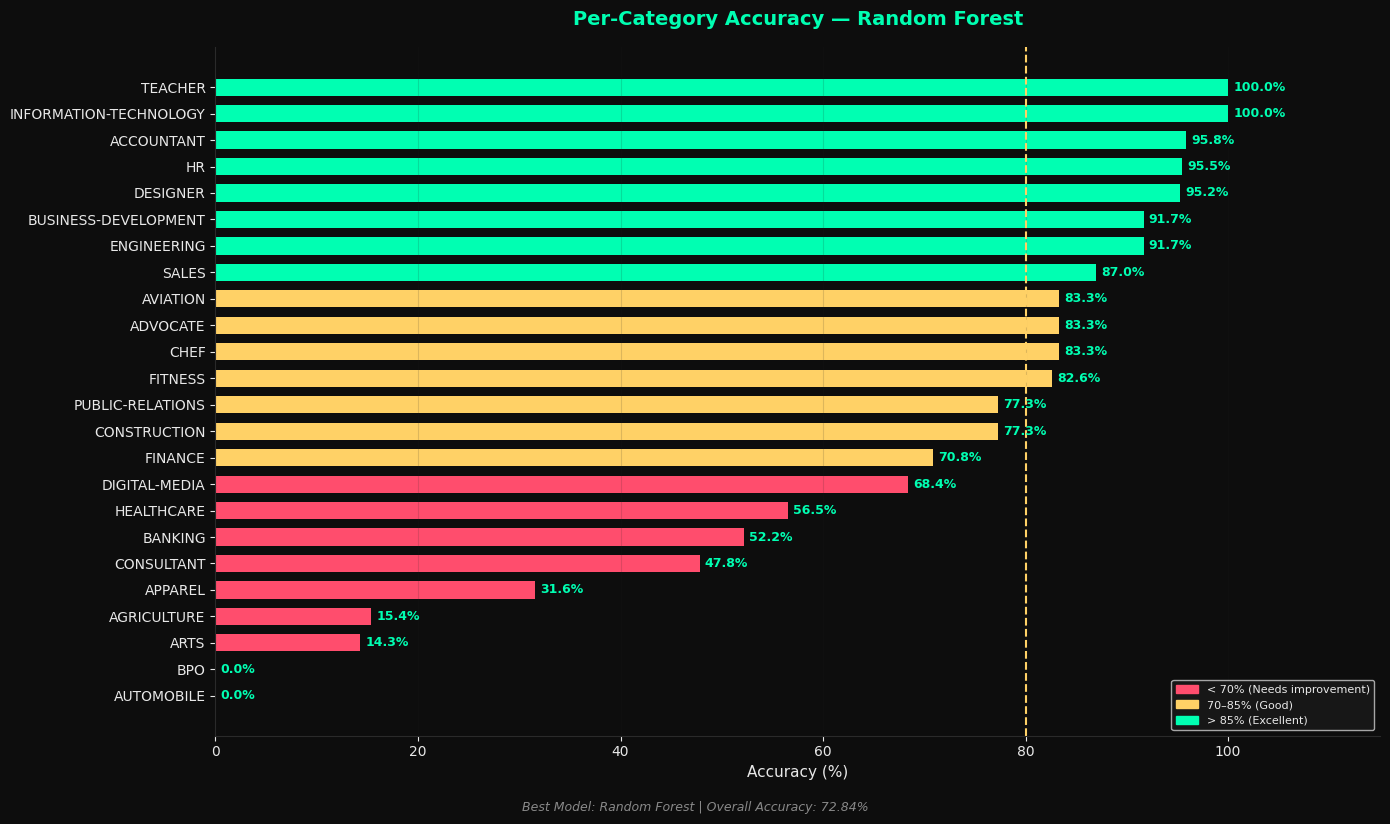

✅ Fig 9 — Per-Class Accuracy saved


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — BEST MODEL DETAILED EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print(f"STEP 6 — Detailed Evaluation: {best_model_name}")
print("="*60)

best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# Classification Report
print(f"\n📋 Classification Report ({best_model_name}):")
print(classification_report(y_test, y_pred_best,
                             target_names=le.classes_,
                             digits=3))

# ── Figure 8: Confusion Matrix ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14), facecolor=BG)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax, linewidths=0.3, linecolor='#1A1A1A',
            annot_kws={'size': 8})
ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=15, fontweight='bold', color=ACCENT1, pad=18)
ax.set_xlabel('Predicted Label', fontsize=11, labelpad=10)
ax.set_ylabel('True Label',      fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
fig.text(0.5, 0.01,
         'Each cell shows number of resumes predicted for each category pair',
         ha='center', fontsize=9, color='#888888', style='italic')
plt.tight_layout()
plt.savefig('fig8_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Fig 8 — Confusion Matrix saved")

# ── Figure 9: Per-class Accuracy ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)

per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
sorted_idx   = np.argsort(per_class_acc)
sorted_cats  = le.classes_[sorted_idx]
sorted_acc   = per_class_acc[sorted_idx]
bar_colors   = [ACCENT2 if v < 70 else ACCENT3 if v < 85 else ACCENT1
                for v in sorted_acc]

bars = ax.barh(sorted_cats, sorted_acc, color=bar_colors, edgecolor='none', height=0.65)
for bar, val in zip(bars, sorted_acc):
    ax.text(val + 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9, color=ACCENT1, fontweight='bold')

ax.axvline(x=80, color=ACCENT3, linestyle='--', lw=1.5, label='80% threshold')
ax.set_xlim(0, 115)
ax.set_title(f'Per-Category Accuracy — {best_model_name}',
             fontsize=14, fontweight='bold', color=ACCENT1, pad=16)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.legend(fontsize=9, facecolor='#1A1A1A')
ax.grid(axis='x', alpha=0.15)
ax.spines[['top','right']].set_visible(False)

legend_patches = [
    mpatches.Patch(color=ACCENT2, label='< 70% (Needs improvement)'),
    mpatches.Patch(color=ACCENT3, label='70–85% (Good)'),
    mpatches.Patch(color=ACCENT1, label='> 85% (Excellent)'),
]
ax.legend(handles=legend_patches, fontsize=8, facecolor='#1A1A1A', loc='lower right')

fig.text(0.5, -0.02,
         f'Best Model: {best_model_name} | Overall Accuracy: {best_accuracy}%',
         ha='center', fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('fig9_per_class_accuracy.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Fig 9 — Per-Class Accuracy saved")

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — SAVE BEST MODEL
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 7 — Saving Best Model")
print("="*60)

model_data = {
    'model'          : best_model,
    'tfidf'          : tfidf,
    'label_encoder'  : le,
    'best_model_name': best_model_name,
    'accuracy'       : best_accuracy,
    'classes'        : list(le.classes_),
}

with open('resume_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f"✅ Model saved → resume_model.pkl")
print(f"   Model       : {best_model_name}")
print(f"   Accuracy    : {best_accuracy}%")
print(f"   Classes     : {len(le.classes_)}")
print(f"   TF-IDF vocab: {len(tfidf.vocabulary_)}")


STEP 7 — Saving Best Model
✅ Model saved → resume_model.pkl
   Model       : Random Forest
   Accuracy    : 72.84%
   Classes     : 24
   TF-IDF vocab: 5000


In [11]:


# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — TEST THE SAVED MODEL (Prediction Demo)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("STEP 8 — Model Prediction Demo")
print("="*60)

# Load and test
with open('resume_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

def predict_category(resume_text):
    cleaned = clean_text(resume_text)
    vec     = loaded['tfidf'].transform([cleaned])
    pred    = loaded['model'].predict(vec)[0]
    return loaded['label_encoder'].inverse_transform([pred])[0]

# Test with sample resumes from each category
test_samples = {
    'IT Resume'      : "Python developer with AWS cloud experience, Docker, Kubernetes, CI/CD pipelines, REST API development, SQL databases, agile methodology",
    'Finance Resume' : "Financial analyst with Excel modeling, SAP, Bloomberg terminal, GAAP compliance, CFA certified, investment portfolio management, variance analysis",
    'HR Resume'      : "Human resources manager with recruitment, talent acquisition, Workday HRIS, payroll processing, employee engagement, SHRM certified",
    'Healthcare'     : "Clinical healthcare administrator with HIPAA compliance, Epic EHR, patient care coordination, medical billing, ICD-10 coding",
    'Engineering'    : "Mechanical engineer with AutoCAD, SolidWorks, MATLAB, structural analysis, ASME standards, project management MS Project",
}

print("\n🔮 Sample Predictions:\n")
for sample_name, sample_text in test_samples.items():
    predicted = predict_category(sample_text)
    print(f"   Input    : {sample_name}")
    print(f"   Predicted: {predicted}")
    print()





STEP 8 — Model Prediction Demo

🔮 Sample Predictions:

   Input    : IT Resume
   Predicted: INFORMATION-TECHNOLOGY

   Input    : Finance Resume
   Predicted: BANKING

   Input    : HR Resume
   Predicted: HR

   Input    : Healthcare
   Predicted: HEALTHCARE

   Input    : Engineering
   Predicted: ENGINEERING



In [12]:
# ── Final Summary ──────────────────────────────────────────────────────────────
print("="*60)
print("📋 FINAL MODEL SUMMARY")
print("="*60)
print(f"\n   Best Model    : {best_model_name}")
print(f"   Test Accuracy : {results[best_model_name]['accuracy']}%")
print(f"   F1 Score      : {results[best_model_name]['f1_score']}%")
print(f"   CV Mean       : {results[best_model_name]['cv_mean']}% ± {results[best_model_name]['cv_std']}%")
print(f"   Saved as      : resume_model.pkl")
print(f"\n   Output Files:")
print(f"   → fig7_model_comparison.png")
print(f"   → fig8_confusion_matrix.png")
print(f"   → fig9_per_class_accuracy.png")
print(f"   → resume_model.pkl")

print("\n" + "="*60)
print("🎯 MODEL BUILDING COMPLETE!")
print("   Next → app.py will load resume_model.pkl")
print("   to predict resume category & optimize keywords")
print("="*60)


📋 FINAL MODEL SUMMARY

   Best Model    : Random Forest
   Test Accuracy : 72.84%
   F1 Score      : 69.82%
   CV Mean       : 71.46% ± 0.58%
   Saved as      : resume_model.pkl

   Output Files:
   → fig7_model_comparison.png
   → fig8_confusion_matrix.png
   → fig9_per_class_accuracy.png
   → resume_model.pkl

🎯 MODEL BUILDING COMPLETE!
   Next → app.py will load resume_model.pkl
   to predict resume category & optimize keywords


In [13]:
# ── Download outputs ───────────────────────────────────────────────────────────
from google.colab import files
files.download('fig7_model_comparison.png')
files.download('fig8_confusion_matrix.png')
files.download('fig9_per_class_accuracy.png')
files.download('resume_model.pkl')
print("\n✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
